In [1]:
# Esame 654AA - a.a. 2025/2026
# Studenti: Leonardo Celati, Samuele Taviano
# Matricole: 660185, ?

In [2]:
from sklearn.preprocessing import StandardScaler

import cup_common as cc
import nn_common as nnc
import cross_common as cr
import torch
import torch.nn as nn
import importlib
from functools import partial
import pandas as pd
import copy
from cross_common import MEE,MSE,RMSE,MAE,R2

importlib.reload(nnc)
importlib.reload(cc)
importlib.reload(cr)

<module 'cross_common' from '/Users/leonardo/workspace/library/source/it.unipi.654AA/notebooks/cross_common.py'>

<h1>NN - Manual</h1>
<h2>Exploring the cup dataset with NN Classifier.</h2>
<p>This notebook serves the purpose of exploring the hypotesis space by manually varying the hyperparameters and for inspecting the whole pipeline.</p>
<hr/>

<h3>Preparation</h3>
<hr/>

<h4>Data preparation</h4>
<p>The train and test dataset are loaded in form of Pandas DataFrame for better interaction with PyTorch.
Eventually there will be these objects:
<ul>
<li>X_tr, y_tr: the train features and train labels (or classes)</li>
<li>X_ts, y_ts: the test features and test labels (or classes)</li>
</ul>
</p>

In [3]:
importlib.reload(cr)
df_train, df_test = cc.load_set()

# Scaler
scaler = StandardScaler()
# The train set used for model selection
# and final testing
X_tr, y_tr = cc.prepare_dataset(df_train)
X_ts, y_ts = cc.prepare_dataset(df_test)

# Important!!!! The following dataset is prepared for investigation purpose and dry run of the NN pipeline,
# in order to check for correctness of function calls and graphics plot
# it is absolutely not meant to be used for model selection
dry_run_scaler = StandardScaler()
X_tr_dry_run, y_tr_dry_run, X_ts_dry_run, y_ts_dry_run = cc.prepare_dataset_for_hold_out(df_train, ratio=0.2, scaler=dry_run_scaler)

features_names = X_tr.columns
cr.dataset_introspection(X_tr, X_ts)

,Property,Training,Test
0,Number of samples,500,1000
1,Number of features,10,10
2,Class values,[],[]
3,Class balance,[],[]


<h4>Network Architecture</h4>
<p>Defining and selecting a hypothesis space with hyper-parameter around a neural network architecture:
<ul>
<li><b>net</b>: represent the internal NN structure with input, hidden and output layer.
One important thing to consider is that the output layer <u>must be kept linear</u> in order to be able to
plug the loss function and the output adapter</li>
<li><b>output_adapter</b>: the function which takes the output from the NN and apply the latest trasformation (classification, regression, etc...).
Must be coherent with the optimizer_template. See function docs for details</li>
<li><b>model_template</b>: the model itself, a skeleton which holds the net structure, and the output adapter function.
The model is always cloned troughout the notebok, just to keep a template reference.</li>
<li><b>optimizer_template</b>: the weight update algorithm</li>
<li><b>scheduler_template</b>: implements adaptive learning rate decay by using ReduceLROnPlateau together with the optimizer template</li>
</ul>
</p>

In [4]:
# Set to True when model is selcted and assessed
dump_prediction = False

# The seed to be used by data splitter
default_state = 42
default_seed = 1

# Starting learning rate
learning_rate = 0.00800621749027941 #2e-3 #1e-3
weight_decay = 1.813565767699133e-05 #1e-5


# The input dimension (i.e. the input layer) is obviously
# the number of feature of the TR set
input_dimension = X_tr.shape[1]
output_dimension = 4


# ----- Defining model architecture --------
hidden_layers = [128,64]
net = nnc.build_nn_net(input_dimension, output_dimension, hidden_layers, "relu")

# The output and loss function, must be changed according to the type of task
#loss_function = nn.MSELoss()
loss_function = nnc.MEELoss()
output_adapter = nnc.regression_adapter()

# Model implementation
model_template = nnc.MLP(net, output_adapter)
# weights initialization (for academic purposes only)
model_template.apply(lambda m: nnc.init_weights(m, method="kaiming", nonlinearity="relu"))
# ------------------------------------------


# -------The weight update algorithm -------
optimizer_template = partial(
    torch.optim.AdamW,
    lr=learning_rate,
    weight_decay=weight_decay,
    betas=(0.95, 0.999)
)
# ------------------------------------------


# ---------- Learning rate decay -----------
# The factor by learning rate will decrease
learning_rate_decay_factor = 0.5 #0.7    #0.6 #0.5
# The epoch to wait before applying the rate decay factor
learning_rate_decay_patience = 10
# The threshold for measuring the new optimum
learning_rate_decay_threshold = 1e-2 #1e-4

# The learning rate decay function
scheduler_template = partial(
    torch.optim.lr_scheduler.ReduceLROnPlateau,
    mode="min", factor=learning_rate_decay_factor, patience=learning_rate_decay_patience,
    threshold=learning_rate_decay_threshold
)
# ------------------------------------------


# --------- Early Stopping Strategy --------
early_stopping_patience = 30 # how many epochs to wait before stopping
early_stopping_min_delta = 1e-2 #1e-4 # the treshold or delta to declare an epochs as not improved
early_stopping_strategy = nnc.EarlyStoppingStrategy(patience=early_stopping_patience, min_delta=early_stopping_min_delta)
# ------------------------------------------


<h3>NN Run</h3>
<p>The NN run is separated in two distinct scenarios independent from each other:
<ol>
<li>Hold-out: meant to be used for inspecting the correctness of the whole pipeline (i.e. no error, effectiveness of learning rate decay, plotting etc...).</li>
<li>KFold: meant to be used for model selection and asessment eventually leading to testing evaluation.</li>
</ol>
</p>
<hr/>

<h4>Hold-out</h4>
<p>Hold-out validation is used for preliminary inspection of learning dynamics, and performed trough a specific dry run set elaborated from the original train set, whereas final model selection based on K-Fold cross-validation.</p>

<h5>Training</h5>
<p>Training the model.</p>

In [5]:
importlib.reload(nnc)
importlib.reload(cr)
# custom settings
# Either batch, online or the mini-batch size
ho_batch_size="batch"
ho_epochs=300
# Enabling Early stopping
ho_patience = 50 # patience <0 will disable early stopping
ho_min_delta = 1e-4 # ignored if early stopping disabled

# Clone an untrained model and its optimizer
model_dry_run = copy.deepcopy(model_template)

hold_out_result = nnc.train(
    model_dry_run, nnc.HoldOutStrategy(nnc.FeatureTargetSet(X_tr, y_tr), seed=default_seed, scaler=dry_run_scaler),
    optimizer_template,loss_function, batch_size=ho_batch_size, epochs_record=ho_epochs,
    early_stopping_strategy=nnc.EarlyStoppingStrategy(patience=ho_patience, min_delta=ho_min_delta),
    scheduler_template=scheduler_template
)


Early stopping at epoch 237 (best VL mee loss: 25.2606)
Train summary
----------------------------------------------------------------------------------------------------
Epochs          | 300
Train           | samples: 400
Validation      | samples: 100
Batch type      | batch
Loss function   | MEELoss(reduction='mean') - custom function
Optimizer       | class: <class 'torch.optim.adamw.AdamW'> , params: {'lr': 0.00800621749027941, 'weight_decay': 1.813565767699133e-05, 'betas': (0.95, 0.999)}
LR Decay        | params: {'mode': 'min', 'factor': 0.5, 'patience': 10, 'threshold': 0.01}
Early Stopping  | metric: mee,  patience: 50 , minimum delta: 0.0001
----------------------------------------------------------------------------------------------------


In [6]:
epochs_tr = hold_out_result.epochs_tr_mse
epochs_vl = hold_out_result.epochs_vl_mse
epochs_tr_mee = hold_out_result.epochs_tr_mee
epochs_vl_mee = hold_out_result.epochs_vl_mee
epochs_grad = hold_out_result.epochs_grad

<h5>Gradient Norm</h5>
<p>The gradient norm should gradually decrease throughout epochs, indicating that the optimization process moves toward a stable region of the loss landscape.</p>

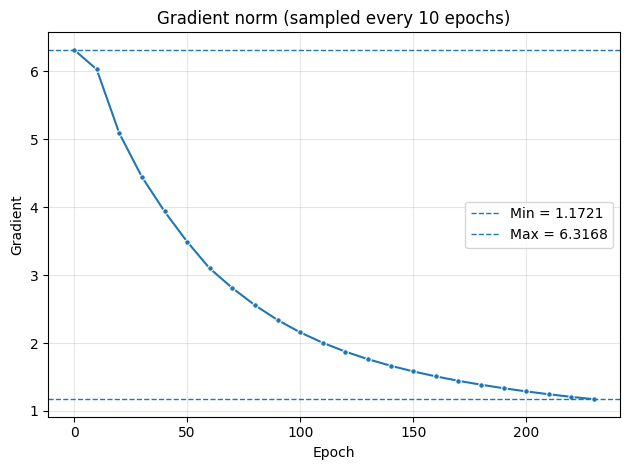

In [7]:
importlib.reload(nnc)
nnc.plot_gradient_norm_line(epochs_grad, step=10)

<h5>Epoch Loss</h5>

<Figure size 640x480 with 0 Axes>

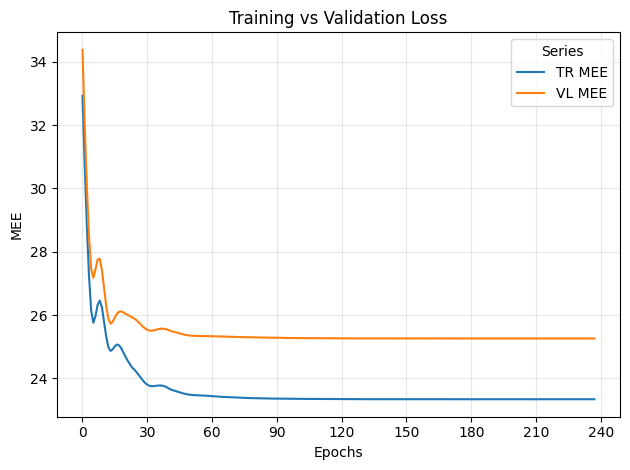

In [8]:
importlib.reload(nnc)
nnc.plot_epoch_mee(epochs_tr_mee, epochs_vl_mee)

In [9]:
print("min MEE: {} - best epoch: {}".format(hold_out_result.min_vl_mee, hold_out_result.best_mee_epoch))


min MEE: 25.260522842407227 - best epoch: 228


<hr/>

<h4>KFold</h4>
<p>Model selection is performed using K-Fold cross-validation on the training data, while an initial hold-out split was used only for preliminary analysis and debugging.</p>

<h5>Run</h5>

In [10]:
importlib.reload(nnc)
importlib.reload(cc)

# The KFold strategy to be used through all models
outer_cv = cr.common_fold_strategy()

# Epochs
kv_epochs=1000
kv_batch_size=64
#kv_batch_size="batch"

inner_train_params = {
    "epochs": kv_epochs,
    "batch_size": kv_batch_size,
    "scheduler_template": scheduler_template,
    "optimizer_template": optimizer_template,
    "loss_function": loss_function,
    "early_stopping_strategy": early_stopping_strategy
}

fold_histories = nnc.kfold(
    model_template, X_tr, y_tr, outer_cv, inner_train_params, scaler
)


  
Perform fold: 0, train size: 400, val size: 100
Early stopping at epoch 100 (best VL mee loss: 22.0822)
Train summary
----------------------------------------------------------------------------------------------------
Epochs          | 1000
Train           | samples: 400
Validation      | samples: 100
Batch type      | mini-batch (64)
Loss function   | MEELoss(reduction='mean') - custom function
Optimizer       | class: <class 'torch.optim.adamw.AdamW'> , params: {'lr': 0.00800621749027941, 'weight_decay': 1.813565767699133e-05, 'betas': (0.95, 0.999)}
LR Decay        | params: {'mode': 'min', 'factor': 0.5, 'patience': 10, 'threshold': 0.01}
Early Stopping  | metric: mee,  patience: 30 , minimum delta: 0.01
----------------------------------------------------------------------------------------------------
  
Perform fold: 1, train size: 400, val size: 100
Early stopping at epoch 129 (best VL mee loss: 21.4409)
Train summary
--------------------------------------------------------

In [11]:
model_baseline = cr.model_baseline(X_tr, y_tr, outer_cv)

----------------------------------------
Baseline: DummyRegressor()
Mean baseline: 35.79302825927734
Scorer: make_scorer(neg_mean_euclidean_error, greater_is_better=False, response_method='predict')
Raw scores: [-36.10307312 -34.5480423  -35.62013626 -35.9157486  -36.77814102]


<h5>Metrics</h5>
<p>Main metrics used for model assessment.
</p>

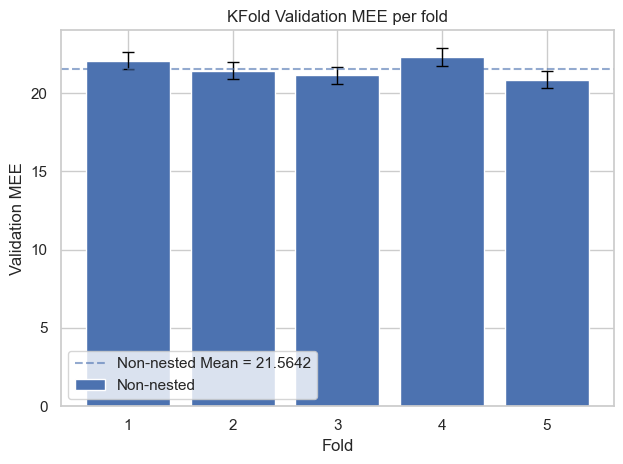

,TR,VL,Gap(TR-VL),Rel Gap(TR-VL)%
Fold,,,,
1,18.111770,22.079498,3.967728,21.91%
2,19.336384,21.436520,2.100136,10.86%
3,18.060328,21.133810,3.073483,17.02%
4,17.250434,22.314168,5.063734,29.35%
5,16.839103,20.857074,4.017971,23.86%
MEAN,17.919604,21.564214,3.644610,20.60%
STD,0.959071,0.618375,1.114597,7.01%


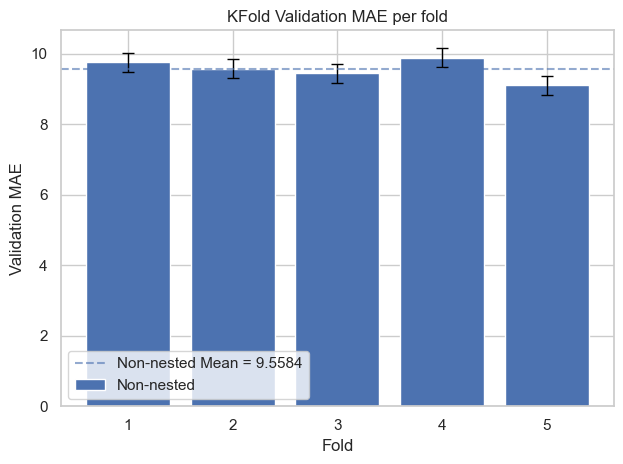

,TR,VL,Gap(TR-VL),Rel Gap(TR-VL)%
Fold,,,,
1,8.033382,9.766433,1.733051,21.57%
2,8.672705,9.579654,0.906949,10.46%
3,8.050151,9.450198,1.400047,17.39%
4,7.635709,9.885598,2.249888,29.47%
5,7.523129,9.110352,1.587223,21.10%
MEAN,7.983015,9.558447,1.575432,20.00%
STD,0.451340,0.301348,0.489261,6.91%


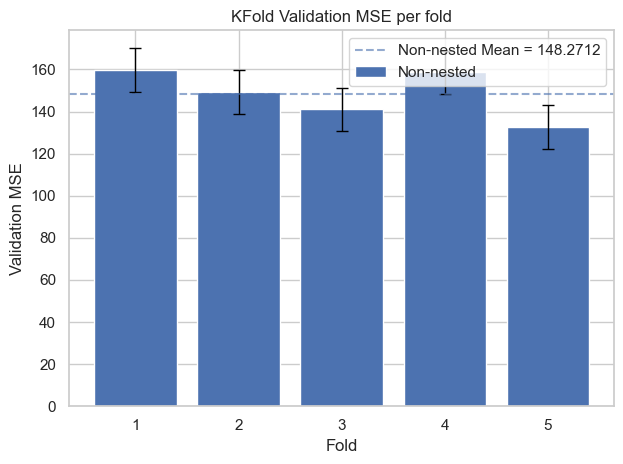

,TR,VL,Gap(TR-VL),Rel Gap(TR-VL)%
Fold,,,,
1,112.811077,159.722324,46.911246,41.58%
2,126.545244,149.313736,22.768492,17.99%
3,113.012625,141.087993,28.075368,24.84%
4,104.253613,158.594821,54.341208,52.12%
5,102.381328,132.637037,30.255709,29.55%
MEAN,111.800777,148.271182,36.470405,33.22%
STD,9.559999,11.563064,13.464939,13.63%


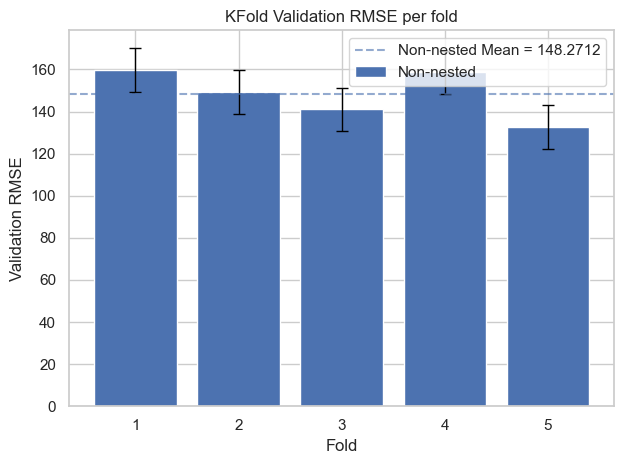

,TR,VL,Gap(TR-VL),Rel Gap(TR-VL)%
Fold,,,,
1,112.811077,159.722324,46.911246,41.58%
2,126.545244,149.313736,22.768492,17.99%
3,113.012625,141.087993,28.075368,24.84%
4,104.253613,158.594821,54.341208,52.12%
5,102.381328,132.637037,30.255709,29.55%
MEAN,111.800777,148.271182,36.470405,33.22%
STD,9.559999,11.563064,13.464939,13.63%


In [12]:
for metric in [MEE,MAE,MSE,RMSE]:
    cr.plot_kfold_metric([(fold_histories,"Non-nested")], metric)
    display(cr.kfold_regression_table(fold_histories, use=metric))

<h5>Bootstrap Variance</h5>

In [19]:
importlib.reload(cr)
importlib.reload(nnc)
bootstrap_samples = 50
bootstrap_rstate = 42
samples = cr.generate_bootstrap_samples_from_dataset(X_tr, y_tr, n_samples=bootstrap_samples, random_state=bootstrap_rstate)
runner = nnc.TorchRegressorRunner(model_template)

bootstrap_params = {}
bootstrap_params['train_params'] = copy.deepcopy(inner_train_params)
bootstrap_params['train_params']["silence_output"] = True
bootstrap_params['scaler'] = scaler
bootstrap_params['split_strategy'] = nnc.HoldOutStrategy
bootstrap_scores = cr.bootstrap_out_of_bag_scores(runner, X_tr, y_tr, samples, bootstrap_params)

IndexError: tuple index out of range

In [ ]:
cr.aggregate_scores(bootstrap_scores)

In [ ]:
cr.plot_bootstrap_distribution([metric.mee for metric in bootstrap_scores])

In [ ]:
save_report = False
if save_report:
    metrics={}
    for metric, value in zip(["mee", "mse", "mae"],[
        ([f.fold_vl_mee for f in fold_histories],[f.fold_tr_mee for f in fold_histories]),
        ([f.fold_vl_mse for f in fold_histories],[f.fold_tr_mse for f in fold_histories]),
        ([f.fold_vl_mae for f in fold_histories],[f.fold_tr_mae for f in fold_histories])
        ]):

        metrics[metric] = (cr.mean_std_from_kfold(value[0]), cr.mean_std_from_kfold(value[1]))
        nnc.save_run_report(model_baseline, net,inner_train_params,metrics)

<h5>Training</h5>
<p>Model is eventually trained with best parameters verified from KFold, in order to predict on official test set.</p>

In [ ]:
# Prepare and scale datasets
X_tr, y_tr = cc.prepare_dataset(df_train, scaler=scaler, fit_scaler=True)   # fit+transform
X_ts, y_ts = cc.prepare_dataset(df_test,  scaler=scaler, fit_scaler=False)

model_final = copy.deepcopy(model_template)
final_scaler = StandardScaler()
train_kf_result = nnc.train(
    model_final, nnc.HoldOutStrategy(nnc.FeatureTargetSet(X_tr, y_tr), val_ratio=0.1, scaler=final_scaler),
    **inner_train_params
)

In [ ]:
epochs_kf_vl_mee = train_kf_result.epochs_vl_mee
epochs_kf_tr_mee = train_kf_result.epochs_tr_mee
epochs_kf_tr_mse = train_kf_result.epochs_tr_mse
epochs_kf_vl_mse = train_kf_result.epochs_vl_mse
epochs_kf_vl_mae = train_kf_result.epochs_vl_mae
epochs_kf_tr_mae = train_kf_result.epochs_tr_mae
epochs_kf_grad = train_kf_result.epochs_grad


<h5>Gradient Norm</h5>
<p>The gradient norm should gradually decrease throughout epochs, indicating that the optimization process moves toward a stable region of the loss landscape.</p>

In [ ]:
importlib.reload(nnc)
nnc.plot_gradient_norm_line(epochs_kf_grad, step=10)

<h5>Epoch Loss</h5>

In [ ]:
importlib.reload(nnc)
nnc.plot_epoch_mee(epochs_kf_tr_mee, epochs_kf_vl_mee)

<h3>Prediction</h3>
<p>Final model prediction if needed.</p>

In [ ]:
importlib.reload(nnc)
all_pred = model_final.predict(X_ts)
print(all_pred)
